In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline 

In [26]:
df=pd.read_csv('creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [27]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [28]:
df['Class'].value_counts()
#highly imbalanced

Class
0    284315
1       492
Name: count, dtype: int64

1. Resampling

In [29]:
#Note: Not really sure if resampling is the best technique, considering the MASSIVE difference b/w the class valuecounts, so I'm just using this data as an example.
#If I actually ever have to do something with data like this, I'll probably do something different, this is just an example
from sklearn.utils import resample
df_majority=df.loc[df['Class']==0]
df_minority=df.loc[df['Class']==1]
print(df_majority.shape, df_minority.shape)

(284315, 31) (492, 31)


In [30]:
df_minority_upsampled=resample(df_minority,replace=True,n_samples=df_majority.shape[0],random_state=42)
df_minority_upsampled.shape

(284315, 31)

In [31]:
df_upsampled=pd.concat([df_majority,df_minority_upsampled])

In [32]:
df_upsampled['Class'].value_counts()

Class
0    284315
1    284315
Name: count, dtype: int64

SMOTE (Synthetic Minority Oversampling Technique)

In [33]:
from imblearn.over_sampling import SMOTE
sm=SMOTE(sampling_strategy='minority',random_state=42)
oversampled_X,oversampled_Y=sm.fit_resample(df.drop('Class',axis=1),df['Class'])
oversampled=pd.concat([pd.DataFrame(oversampled_X),pd.DataFrame(oversampled_Y)],axis=1)

In [34]:
oversampled

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000000,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.620000,0
1,0.000000,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690000,0
2,1.000000,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.660000,0
3,1.000000,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.500000,0
4,2.000000,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.990000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568625,144838.659385,-6.379157,1.672637,-5.885670,2.068340,-0.668576,-3.336450,-4.995823,2.632847,-2.275158,...,0.641337,-0.249308,-2.311290,-0.159402,1.190079,-0.258067,0.777265,-0.728919,7.334751,1
568626,65965.011763,-2.479028,0.958932,-1.782249,1.541783,-1.191990,-0.466794,-1.957161,0.312580,-0.433956,...,0.351983,0.208869,-0.235986,-0.404446,0.220454,0.685263,-0.890346,0.598736,74.507571,1
568627,34592.129093,-1.799894,2.368957,-2.673997,1.705968,-1.355923,-1.121788,-2.057832,-1.677459,-0.659287,...,1.473371,-0.581778,-0.013899,-0.144597,0.120315,0.242272,-0.121166,-0.534238,102.486823,1
568628,129683.002907,0.255234,2.432041,-5.388252,3.793925,-0.230814,-1.382725,-1.572929,0.748305,-1.600633,...,0.316760,-0.036858,0.182968,0.190701,-0.339250,-0.272824,0.315507,-0.091005,58.346854,1


In [35]:
oversampled['Class'].value_counts()

Class
0    284315
1    284315
Name: count, dtype: int64

BalancedBaggingClassifier

In [36]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop('Class',axis=1),df['Class'],test_size=0.3)

In [37]:
from sklearn.tree import DecisionTreeClassifier
clf=DecisionTreeClassifier()
clf.fit(X_train,y_train)

DecisionTreeClassifier()

In [38]:
from sklearn.metrics import classification_report
clf_report = pd.DataFrame(classification_report(y_test, clf.predict(X_test), output_dict=True))
clf_report

,0,1,accuracy,macro avg,weighted avg
precision,0.999578,0.701863,0.999017,0.850721,0.999059
recall,0.999437,0.758389,0.999017,0.878913,0.999017
f1-score,0.999508,0.729032,0.999017,0.864270,0.999036
support,85294.000000,149.000000,0.999017,85443.000000,85443.000000


Text(0.5, 1.0, 'Accuracy Score: 0.9990168884519505')

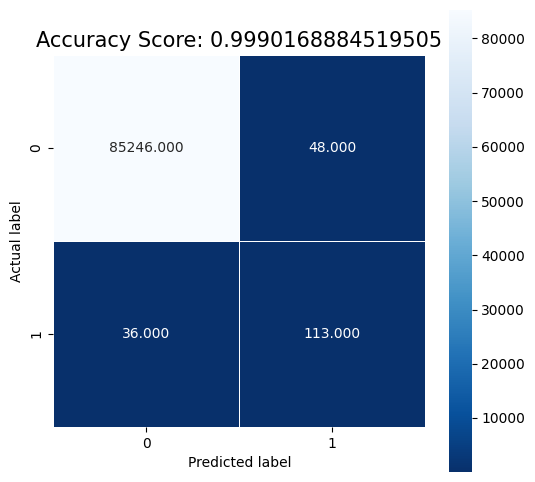

In [39]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,clf.predict(X_test))
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score: {0}'.format(clf.score(X_test,y_test))
plt.title(all_sample_title, size = 15)

In [40]:
from imblearn.ensemble import BalancedBaggingClassifier
classifier=BalancedBaggingClassifier(estimator=DecisionTreeClassifier(),sampling_strategy='not majority',replacement=True,random_state=42)
classifier.fit(X_train,y_train)

BalancedBaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42,
                          replacement=True, sampling_strategy='not majority')

In [41]:
clf_report2 = pd.DataFrame(classification_report(y_test, classifier.predict(X_test), output_dict=True))
clf_report2

,0,1,accuracy,macro avg,weighted avg
precision,0.999555,0.940678,0.999473,0.970116,0.999452
recall,0.999918,0.744966,0.999473,0.872442,0.999473
f1-score,0.999736,0.831461,0.999473,0.915598,0.999443
support,85294.000000,149.000000,0.999473,85443.000000,85443.000000


Text(0.5, 1.0, 'Accuracy Score: 0.9994733330992591')

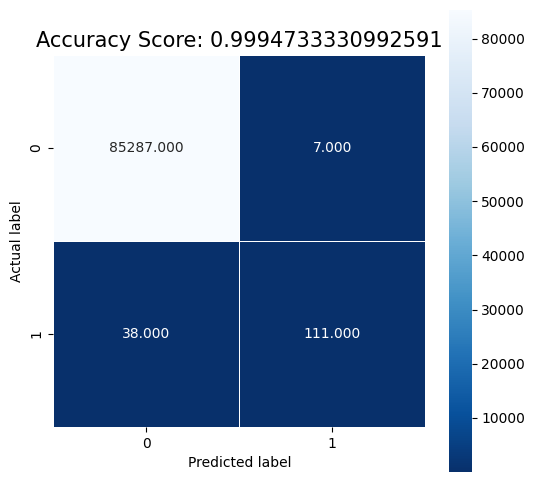

In [42]:
cm=confusion_matrix(y_test,classifier.predict(X_test))
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score: {0}'.format(classifier.score(X_test,y_test))
plt.title(all_sample_title, size = 15)

Finding optimal threshold for classification

In [43]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
prob=rf.predict_proba(X_test)
prob

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [44]:
pd.DataFrame(prob)
print(pd.DataFrame(prob)[0].unique(),pd.DataFrame(prob)[1].unique())

[1.   0.92 0.99 0.07 0.1  0.98 0.03 0.97 0.68 0.23 0.95 0.86 0.65 0.19
 0.96 0.01 0.02 0.94 0.93 0.04 0.69 0.11 0.81 0.52 0.13 0.05 0.21 0.15
 0.87 0.89 0.51 0.34 0.   0.08 0.26 0.6  0.53 0.06 0.91 0.88 0.54 0.18
 0.72 0.14 0.7  0.55 0.5  0.83 0.76 0.29 0.57 0.67 0.25 0.16 0.4  0.09
 0.61 0.45 0.2  0.31 0.74 0.77 0.24 0.33 0.85 0.82 0.27 0.28 0.73 0.9
 0.12] [0.   0.08 0.01 0.93 0.9  0.02 0.97 0.03 0.32 0.77 0.05 0.14 0.35 0.81
 0.04 0.99 0.98 0.06 0.07 0.96 0.31 0.89 0.19 0.48 0.87 0.95 0.79 0.85
 0.13 0.11 0.49 0.66 1.   0.92 0.74 0.4  0.47 0.94 0.09 0.12 0.46 0.82
 0.28 0.86 0.3  0.45 0.5  0.17 0.24 0.71 0.43 0.33 0.75 0.84 0.6  0.91
 0.39 0.55 0.8  0.69 0.26 0.23 0.76 0.67 0.15 0.18 0.73 0.72 0.27 0.1
 0.88]


In [45]:
rf.score(X_test,y_test)

0.9994616293903538

In [46]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, rf.predict(X_test))

0.8657366396182301

Text(0.5, 1.0, 'Accuracy Score: 0.9994616293903538')

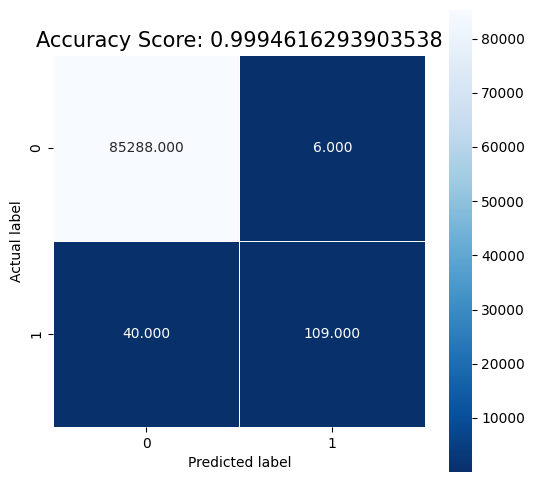

In [47]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,rf.predict(X_test))
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score: {0}'.format(rf.score(X_test,y_test))
plt.title(all_sample_title, size = 15)

In [48]:
step=0.05
threshold=0
roc_score=0

while threshold<=0.9:
    temp_thresh=threshold
    predicted=(prob[:,1]>=temp_thresh).astype('int') #the comparision operation will give bool result, which we change to int
    print('Threshold',temp_thresh,'--',roc_auc_score(y_test, predicted))
    if roc_score<roc_auc_score(y_test,predicted):
        thrsh_score=threshold
        roc_score=roc_auc_score(y_test,predicted)
    threshold=threshold+step
print('---Optimum threshold---',thrsh_score,'---ROC---',roc_score)
#best threshold is 0.05

Threshold 0 -- 0.5
Threshold 0.05 -- 0.9289908902535768
Threshold 0.1 -- 0.9259400135622496
Threshold 0.15000000000000002 -- 0.915954968547006
Threshold 0.2 -- 0.9126109880031217
Threshold 0.25 -- 0.9126285742342751
Threshold 0.3 -- 0.9126520225424797
Threshold 0.35 -- 0.9059699235317622
Threshold 0.39999999999999997 -- 0.8959145335919048
Threshold 0.44999999999999996 -- 0.8892148483500338
Threshold 0.49999999999999994 -- 0.8724421869371521
Threshold 0.5499999999999999 -- 0.8657366396182301
Threshold 0.6 -- 0.8657425016952811
Threshold 0.65 -- 0.8590310922993081
Threshold 0.7000000000000001 -- 0.8422642929634775
Threshold 0.7500000000000001 -- 0.8254857694735446
Threshold 0.8000000000000002 -- 0.8019958365876385
Threshold 0.8500000000000002 -- 0.7785117657787837
---Optimum threshold--- 0.05 ---ROC--- 0.9289908902535768
